In [ ]:
import os
import openslide
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import timm
import networkx as nx
from tqdm import tqdm
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GATConv

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# patch extraction 
def extract_patches(slide_path, patch_size=224, stride=224, max_patches=300):
    slide = openslide.OpenSlide(slide_path)
    W, H = slide.dimensions
    patches, coords = [], []
    for x in range(0, W, stride):
        for y in range(0, H, stride):
            patch = slide.read_region((x, y), 0, (patch_size, patch_size))
            patch = np.array(patch)[:, :, :3]
            if patch.mean() > 220:
                continue

            patches.append(patch)
            coords.append((x, y))
            if len(patches) >= max_patches:
                return np.array(patches), np.array(coords)

    return np.array(patches), np.array(coords)


# VIT feature extraction
vit = timm.create_model('vit_base_patch16_224', pretrained=True)
vit.head = nn.Identity()
vit = vit.to(device)
vit.eval()

def extract_features(patches):
    patches_t = torch.tensor(patches / 255.0).permute(0,3,1,2).float()
    feats = []
    with torch.no_grad():
        for i in range(0, len(patches_t), 32):
            batch = patches_t[i:i+32].to(device)
            f = vit.forward_features(batch)
            f = f.mean(dim=1)
            feats.append(f.cpu())

    return torch.cat(feats)

# graph building and PR computation
def build_graph(coords, k=6):
    return kneighbors_graph(coords, k, mode='distance')

def compute_pagerank(A):
    G = nx.from_scipy_sparse_array(A)
    pr = nx.pagerank(G)
    return np.array([pr[i] for i in range(len(pr))])

# GNN Model
class PageRankGNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.gat = GATConv(in_dim, 128, heads=4)
        self.fc = nn.Linear(128*4, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, pr):
        x = self.gat(x, edge_index)
        x = self.dropout(x)

        pr = (pr - pr.mean()) / (pr.std() + 1e-6)
        x = x + 0.1 * pr.unsqueeze(1) * x

        out = torch.sigmoid(self.fc(x)).squeeze()
        return out  # patch-level predictions


# converting slides to graph data
def process_slide(path, label):
    patches, coords = extract_patches(path)
    if len(patches) == 0:
        return None

    feats = extract_features(patches)
    A = build_graph(coords)
    pr = compute_pagerank(A)

    edge_index = np.vstack(A.nonzero())
    data = Data(
        x=feats,
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor([label]).float()
    )

    data.pr = torch.tensor(pr).float()
    data.coords = coords
    data.path = path

    return data

# loading dataset (30 WSI slides)
def load_dataset(csv_path, img_dir, max_slides=30):
    df = pd.read_csv(csv_path)
    data_list = []
    for i in tqdm(range(max_slides)):
        row = df.iloc[i]
        slide_id = row['image_id']
        label = 1 if row['isup_grade'] > 0 else 0

        path = os.path.join(img_dir, slide_id + ".tiff")
        data = process_slide(path, label)

        if data is not None:
            data_list.append(data)

    return data_list

#training
def train(model, train_data, test_data):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss() 
    for epoch in range(50):
        model.train()
        total_loss = 0
        for data in train_data:

            data = data.to(device)
            data.pr = data.pr.to(device)
            optimizer.zero_grad()

            patch_preds = model(data.x, data.edge_index, data.pr)
            slide_pred = patch_preds.mean().unsqueeze(0)
            target = data.y.view_as(slide_pred)

            loss = criterion(slide_pred, target)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}, Loss {total_loss:.4f}")
        evaluate(model, test_data)

# eval
def evaluate(model, data_list):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for data in data_list:
            data = data.to(device)
            data.pr = data.pr.to(device)
            patch_preds = model(data.x, data.edge_index, data.pr)
            slide_pred = patch_preds.mean().item()
            y_true.append(data.y.item())
            y_prob.append(slide_pred)
            y_pred.append(1 if slide_pred > 0.5 else 0)
            
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"Accuracy: {acc}, AUC: {auc}")

/home/sahil-narkhede/Desktop/Me/SEM6/cv/OncoPRISM-Prototype/onco-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Execution 

After Preprocessing,

Each slide becomes a graph:
- Nodes = patches (224 x 224)
- Features = ViT embeddings
- Edges = spatial neighbors
- pr = PageRank scores
- label = slide label

We aggregate patch-level predictions using mean pooling to obtain a slide-level prediction and optimize using binary cross-entropy loss.

*NOTE: If not saved, we will first train it, then we can use the training data for faster evaluations

In [ ]:
# loading the pre-trained data for faster exection 

def main():
    cwd = os.getcwd()
    candidates = [
        os.path.abspath(os.path.join(cwd, "cache_snapshot", "training_snapshot.pt")),
        os.path.abspath(os.path.join(cwd, "onco-code", "cache_snapshot", "training_snapshot.pt")),
        os.path.abspath(os.path.join(cwd, "..", "cache_snapshot", "training_snapshot.pt")),
        os.path.abspath(os.path.join(cwd, "..", "onco-code", "cache_snapshot", "training_snapshot.pt")),
    ]

    checkpoint_path = next((p for p in candidates if os.path.isfile(p)), None)
    if checkpoint_path is None:
        raise FileNotFoundError(
            f"Could not find training snapshot from cwd={cwd}. Tried: {candidates}"
        )

    snapshot = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model = PageRankGNN(768).to(device)
    if "model_state_dict" in snapshot:
        model.load_state_dict(snapshot["model_state_dict"] )
        model.eval()

    test_data = snapshot.get("test_data", [])
    if len(test_data) == 0:
        raise RuntimeError(
            f"Snapshot loaded from {checkpoint_path} but no test_data found."
        )

    return model, test_data

if __name__ == "__main__":
    model, test_data = main()

In [ ]:
# Main training pipeline
from sklearn.model_selection import train_test_split

def main():
    cwd = os.getcwd()
    candidates = [
        os.path.abspath(os.path.join(cwd, "data", "panda")),
        os.path.abspath(os.path.join(cwd, "..", "data", "panda")),
        os.path.abspath(os.path.join(cwd, "..", "..", "data", "panda")),
    ]

    base_dir = next((p for p in candidates if os.path.isdir(p)), None)
    if base_dir is None:
        raise FileNotFoundError(
            f"Could not find data/panda from cwd={cwd}. Tried: {candidates}"
        )

    csv_path = os.path.join(base_dir, "train.csv")
    img_dir = os.path.join(base_dir, "train_images")

    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"Missing CSV file: {csv_path}")
    if not os.path.isdir(img_dir):
        raise FileNotFoundError(f"Missing image directory: {img_dir}")

    data_list = load_dataset(csv_path, img_dir, max_slides=30)
    if len(data_list) < 2:
        raise RuntimeError(
            f"Loaded {len(data_list)} slides. Need at least 2 valid slides for train/test split."
        )

    labels = [d.y.item() for d in data_list]

    train_data, test_data = train_test_split(
        data_list,
        test_size=0.3,
        stratify=labels
    )
    
    model = PageRankGNN(768).to(device)
    train(model, train_data, test_data)
    return model, test_data


if __name__ == "__main__":
    model, test_data = main()

In [ ]:
# Save a kernel snapshot so you can reload later without retraining
snapshot_dir = "cache_snapshot"
os.makedirs(snapshot_dir, exist_ok=True)

checkpoint_path = os.path.join(snapshot_dir, "training_snapshot.pt")
snapshot = {}

# Save model weights (enough to restore trained model)
if "model" in globals():
    snapshot["model_state_dict"] = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    snapshot["model_class"] = model.__class__.__name__

# Save graph datasets already in memory (train/test/full if they exist)
for var_name in ["train_data", "test_data", "data_list"]:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, list) and (len(obj) == 0 or isinstance(obj[0], Data)):
            snapshot[var_name] = [d.cpu() for d in obj]

# Optional metadata
snapshot["device_when_saved"] = device

torch.save(snapshot, checkpoint_path)
print(f"Saved snapshot to: {checkpoint_path}")
print(f"Saved keys: {list(snapshot.keys())}")

Saved snapshot to: cache_snapshot/training_snapshot.pt
Saved keys: ['model_state_dict', 'model_class', 'test_data', 'device_when_saved']


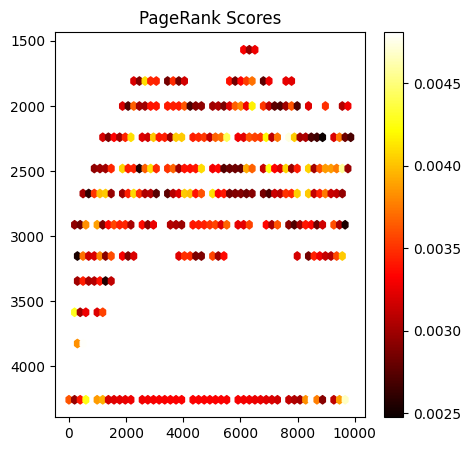

In [ ]:
import matplotlib.pyplot as plt

def plot_heatmap(coords, values, title):
    x = [c[0] for c in coords]
    y = [c[1] for c in coords]

    plt.figure(figsize=(5,5))
    # plt.scatter(x, y, c=values, cmap='hot', s=15)
    plt.hexbin(x, y, C=values, gridsize=50, cmap='hot')
    plt.colorbar()
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()
    
plot_heatmap(test_data[0].coords, test_data[0].pr, "PageRank Scores")

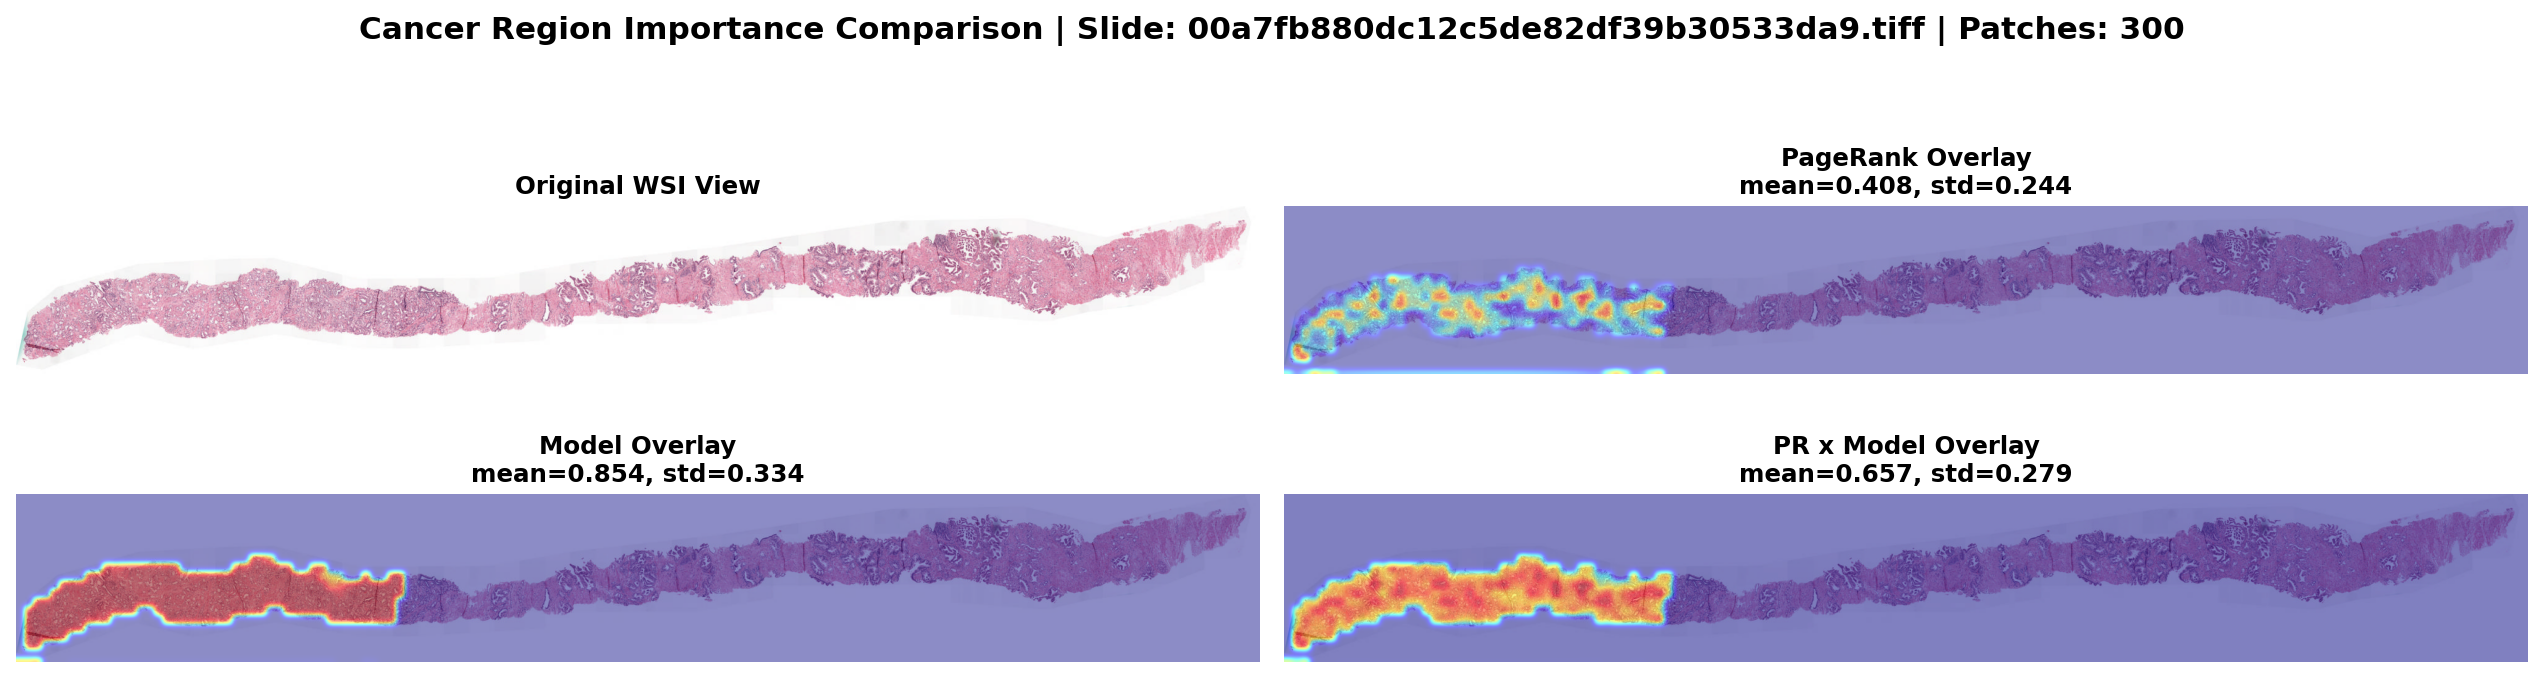

In [ ]:
import openslide
import numpy as np
import matplotlib.pyplot as plt
import cv2
from os.path import basename

def get_patch_predictions(model, data_obj):
    model.eval()
    with torch.no_grad():
        x = data_obj.x.to(device)
        edge_index = data_obj.edge_index.to(device)
        pr = data_obj.pr.to(device)
        preds = model(x, edge_index, pr).detach().cpu().numpy()
    return preds

def overlay_comparison(slide_path, coords, pr, preds, patch_size=224, downsample=32, layout="2x2"):
    slide = openslide.OpenSlide(slide_path)
    level = slide.get_best_level_for_downsample(downsample)
    w, h = slide.level_dimensions[level]

    base = slide.read_region((0, 0), level, (w, h))
    base = np.array(base)[:, :, :3]
    scale = slide.level_downsamples[level]

    def normalize_scores(values):
        values = np.asarray(values, dtype=np.float32)
        lo = np.percentile(values, 2)
        hi = np.percentile(values, 98)
        values = np.clip(values, lo, hi)
        values = (values - values.min()) / (values.max() - values.min() + 1e-6)
        return values

    def create_overlay(values, alpha=0.45):
        values = normalize_scores(values)
        heatmap = np.zeros((h, w), dtype=np.float32)

        for (x, y), score in zip(coords, values):
            x_s = int(x / scale)
            y_s = int(y / scale)
            p_s = max(1, int(patch_size / scale))

            y_e = min(h, y_s + p_s)
            x_e = min(w, x_s + p_s)
            heatmap[y_s:y_e, x_s:x_e] = np.maximum(heatmap[y_s:y_e, x_s:x_e], score)

        heatmap = cv2.GaussianBlur(heatmap, (31, 31), 0)
        heatmap_uint8 = (heatmap * 255).astype(np.uint8)
        heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

        blended = cv2.addWeighted(base, 1.0 - alpha, heatmap_color, alpha, 0)
        return blended, values

    pr_overlay, pr_vals = create_overlay(pr, alpha=0.45)
    model_overlay, model_vals = create_overlay(preds, alpha=0.45)
    combined_overlay, combo_vals = create_overlay(np.asarray(pr) * np.asarray(preds), alpha=0.5)

    panels = [
        ("Original WSI View", base, None),
        (f"PageRank Overlay\nmean={pr_vals.mean():.3f}, std={pr_vals.std():.3f}", pr_overlay, None),
        (f"Model Overlay\nmean={model_vals.mean():.3f}, std={model_vals.std():.3f}", model_overlay, None),
        (f"PR x Model Overlay\nmean={combo_vals.mean():.3f}, std={combo_vals.std():.3f}", combined_overlay, None),
    ]

    if layout == "2x2":
        fig, axes = plt.subplots(2, 2, figsize=(16, 5), dpi=160)
        axes = axes.flatten()
        for ax, (title, img, _) in zip(axes, panels):
            ax.imshow(img)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.axis("off")

    elif layout == "top-3":
        fig = plt.figure(figsize=(18, 10), dpi=160)
        gs = fig.add_gridspec(2, 3, height_ratios=[1.2, 1])

        ax0 = fig.add_subplot(gs[0, :])
        ax0.imshow(base)
        ax0.set_title("Original WSI View", fontsize=12, fontweight="bold")
        ax0.axis("off")

        bottom = [
            (f"PageRank Overlay\nmean={pr_vals.mean():.3f}, std={pr_vals.std():.3f}", pr_overlay),
            (f"Model Overlay\nmean={model_vals.mean():.3f}, std={model_vals.std():.3f}", model_overlay),
            (f"PR x Model Overlay\nmean={combo_vals.mean():.3f}, std={combo_vals.std():.3f}", combined_overlay),
        ]

        for i, (title, img) in enumerate(bottom):
            ax = fig.add_subplot(gs[1, i])
            ax.imshow(img)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.axis("off")

    else:
        raise ValueError("layout must be either '2x2' or 'top-3'")

    fig.suptitle(
        f"Cancer Region Importance Comparison | Slide: {basename(slide_path)} | Patches: {len(coords)}",
        fontsize=14,
        fontweight="bold"
    )
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    plt.show()


sample = test_data[0]
preds = get_patch_predictions(model, sample)

# Choose one layout: "2x2" or "top-3"
overlay_comparison(sample.path, sample.coords, sample.pr.cpu().numpy(), preds, layout="2x2")